## 1. Programa BEM en 3D

# 3D Frequency-Domain Boundary Element Method (BEM)

This tutorial demonstrates the implementation of a 3D Boundary Element Method (BEM) to analyze the interaction between regular linear water waves and submerged porous structures.

The formulation is based on:
- Linear potential flow theory
- Time-harmonic (frequency-domain) analysis
- Boundary integral equation formulation

The objective is to compute:
- Wave transmission and reflection

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

from MESH.MAIN_MESH_SEMI_CIRC import MAIN_MESH_SEMI_CIRC

import meshio

import numpy as np

from ADD_FUNCTIONS.PROCESS_MESH import PROCESS_MESH
from ADD_FUNCTIONS.COORDINATES import COORDINATES
from ADD_FUNCTIONS.ELEMENT_CONNECTION import ELEMENT_CONNECTION
from ADD_FUNCTIONS.COS_DIR import COS_DIR
from ADD_FUNCTIONS.MATCHING import MATCHING

from MATRICES.FUNDA6 import FUNDA6
from MATRICES.FUNDA6_TRI import FUNDA6_TRI
from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.TRILOC6 import TRILOC6

from ADD_FUNCTIONS.POROUS_NODES import POROUS_NODES

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD import BC_FAR_FIELD
from BOUNDARY_CONDITIONS.BC_COMPLEX_G import BC_COMPLEX_G
from BOUNDARY_CONDITIONS.BC_CONSTANT_G import BC_CONSTANT_G
from BOUNDARY_CONDITIONS.BC_INTERFACE import BC_INTERFACE
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from ADD_FUNCTIONS.FX_FUNCTION import FX_FUNCTION
from ADD_FUNCTIONS.ENERGY_FLUX import ENERGY_FLUX
from ADD_FUNCTIONS.NODES_FS import NODES_FS

from ADD_FUNCTIONS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

In [2]:
# Variables of interest

# Water depth
DEPTH         = 0.40;

RADIUS        = 0.36;
WIDTH_CHANNEL = 0.40*DEPTH;

LX = 2.0*DEPTH;

NUM_OF_REG = 4;

gravity = 9.8056
rho     = 999.1033




In [3]:
# GMSH mesh
# MAIN_MESH_SEMI_CIRC(DEPTH,RADIUS,WIDTH_CHANNEL,LX)

In [4]:
# NUMBER OF FREQUENCIES
ttmax = 5

# WAVE PERIODS
kh = np.linspace(0.005, 3.00, ttmax)

HL = 0.01

# # WAVE HEIGHT
# Wave_height = 0.01

# POROUS EFFECT PARAMETER
Gporous = 0.75

In [5]:
# Process the outer region
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("DOMAIN_0.msh")
MESH_1_POS, MESH_1_QUADS9 = PROCESS_MESH("DOMAIN_1.msh")
MESH_2_POS, MESH_2_QUADS9 = PROCESS_MESH("DOMAIN_2.msh")
MESH_3_POS, MESH_3_QUADS9 = PROCESS_MESH("DOMAIN_3.msh")

In [6]:
# Number of nodes per quad element
NCONEC = 9;

In [7]:
# PRE-ASSIGN
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [8]:
N[0] ,  NE[0] ,  KCONEC0 = COORDINATES(MESH_0_POS , MESH_0_QUADS9)
N[1] ,  NE[1] ,  KCONEC1 = COORDINATES(MESH_1_POS , MESH_1_QUADS9)
N[2] ,  NE[2] ,  KCONEC2 = COORDINATES(MESH_2_POS , MESH_2_QUADS9)
N[3] ,  NE[3] ,  KCONEC3 = COORDINATES(MESH_3_POS , MESH_3_QUADS9)

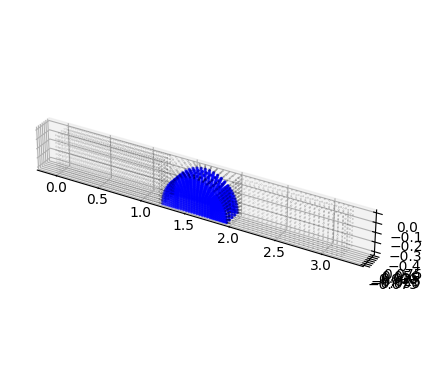

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=0.01
)

ax.scatter(
    MESH_1_POS[:,0],
    MESH_1_POS[:,1],
    MESH_1_POS[:,2],
    c='k',
    s=0.01
)

ax.scatter(
    MESH_2_POS[:,0],
    MESH_2_POS[:,1],
    MESH_2_POS[:,2],
    c='b',
    s=2
)

ax.scatter(
    MESH_3_POS[:,0],
    MESH_3_POS[:,1],
    MESH_3_POS[:,2],
    c='k',
    s=0.01
)

#ax.grid(True)
ax.set_box_aspect([7.5,0.5,1])  # axis equal

plt.show()

In [10]:
# ELEMENT CONNECTION
REF_R0 , NORMAL0 = ELEMENT_CONNECTION(NCONEC , KCONEC0 , MESH_0_POS , NE[0])
REF_R1 , NORMAL1 = ELEMENT_CONNECTION(NCONEC , KCONEC1 , MESH_1_POS , NE[1])
REF_R2 , NORMAL2 = ELEMENT_CONNECTION(NCONEC , KCONEC2 , MESH_2_POS , NE[2])
REF_R3 , NORMAL3 = ELEMENT_CONNECTION(NCONEC , KCONEC3 , MESH_3_POS , NE[3])

In [11]:
# MATCHING NODES BETWEEN TWO ADJACENT REGIONS (INTERFACE)

NODES_MATCH_R0_R1 = MATCHING(REF_R0['OUT'] ,  MESH_0_POS  ,  KCONEC0  ,  REF_R1['IN'] ,  MESH_1_POS  ,  KCONEC1);
NODES_MATCH_R1_R3 = MATCHING(REF_R1['OUT'] ,  MESH_1_POS  ,  KCONEC1  ,  REF_R3['IN'] ,  MESH_3_POS  ,  KCONEC3);

# CYL 1
NODES_MATCH_CYL_1 = MATCHING(REF_R1['POROUS'] ,  MESH_1_POS  ,  KCONEC1  ,  REF_R2['POROUS'] ,  MESH_2_POS  ,  KCONEC2);

In [12]:
N_total = N[0] + N[1] + N[2] + N[3]

In [13]:
KCON_N_0  = KCONEC0[0:9, :]
KCON_N_01 = KCONEC1[0:9, :] + N[0]
KCON_N_02 = KCONEC2[0:9, :] + N[0] + N[1]
KCON_N_03 = KCONEC3[0:9, :] + N[0] + N[1] + N[2]

KCONEC = np.hstack((KCON_N_0, KCON_N_01, KCON_N_02, KCON_N_03))

In [14]:
# FORM SYSTEM OF EQUATIONS FOR EACH REGION

H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC0 , NE[0] , N[0] , DEPTH);
H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC1 , NE[1] , N[1] , DEPTH);
H2 , G2 = GHMAT6(MESH_2_POS , NCONEC , KCONEC2 , NE[2] , N[2] , DEPTH);
H3 , G3 = GHMAT6(MESH_3_POS , NCONEC , KCONEC3 , NE[3] , N[3] , DEPTH);

In [15]:
# MERGE H AND G MATRICES
from scipy.linalg import block_diag
H = np.zeros((N_total, N_total), dtype=np.complex128)

# i0 = 0
# i1 = N[0]
# i2 = i1 + N[1]
# i3 = i2 + N[2]
# i4 = i3 + N[3]   # should equal N_total

# H[i0:i1, i0:i1] = H0
# H[i1:i2, i1:i2] = H1
# H[i2:i3, i2:i3] = H2
# H[i3:i4, i3:i4] = H3

H = block_diag(H0, H1, H2, H3)

NE_total = NE[0] + NE[1] + NE[2] + NE[3]

# G_CONE0  = NCONEC * NE[0]
# G_CONE01 = NCONEC * (NE[0] + NE[1]) 
# G_CONE02 = NCONEC * (NE[0] + NE[1] + NE[2]) 
# G_CONE03 = NCONEC * NE_total

G = np.zeros((N_total, NCONEC * NE_total), dtype=np.complex128)

# G[                   : N[0]               , :          G_CONE0]           = G0
# G[N[0]               : N[0] + N[1]        , G_CONE0  : G_CONE01]          = G2
# G[N[0] + N[1]        : N[0] + N[1] + N[2] , G_CONE01 : G_CONE02]          = G3
# G[N[0] + N[1] + N[2] : N_total            , G_CONE02 : NCONEC * NE_total] = G4

G = block_diag(G0, G1, G2, G3)

In [16]:
# READ THE POROUS NODES IN BOTH REGIONS
[STORE_NODE_R0_out, STORE_NODE_R1_in] = POROUS_NODES(NCONEC, KCONEC0, KCONEC1, MESH_0_POS, MESH_1_POS, NODES_MATCH_R0_R1);
[STORE_NODE_R1_out, STORE_NODE_R3_in] = POROUS_NODES(NCONEC, KCONEC1, KCONEC3, MESH_1_POS, MESH_3_POS, NODES_MATCH_R1_R3);

[STORE_NODE_R1_CYL, STORE_NODE_R2_CYL] = POROUS_NODES(NCONEC, KCONEC1, KCONEC2, MESH_1_POS, MESH_2_POS, NODES_MATCH_CYL_1);

In [17]:
# FREQUENCY ITERATIONS

# Preallocate if not already done
X_axis = np.zeros(ttmax)

CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# ============================
# MAIN LOOP
# ============================

for tt in range(ttmax):

    print(tt + 1)

    X_axis[tt] = kh[tt]

    # WAVE NUMBER
    k = kh[tt] / DEPTH

    # WAVE PERIOD
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # WAVE FREQUENCY
    f = 1.0 / T

    # ANGULAR FREQUENCY
    omega = 2*np.pi*f

    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # SAVE MATRICES
    A = H.copy()
    B = G.copy()

    # ------------------------
    # BOUNDARY CONDITIONS
    # ------------------------
    # FREE SURFACE BC
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R1["FS"], KCONEC, NE, 1)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R3["FS"], KCONEC, NE, 3)

    # FAR FIELD BC
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R0["IN"],  KCONEC, NE, 0)
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R3["OUT"], KCONEC, NE, 3)

    # POROUS STRUCTURE BC
    # A = BC_COMPLEX_G(A, B, k, NCONEC, STORE_NODE_R1_CYL, STORE_NODE_R2_CYL, N, NE, Gporous, 1, 2)
    A = BC_CONSTANT_G(A, B, DEPTH, NCONEC, STORE_NODE_R1_CYL, STORE_NODE_R2_CYL, N, NE, Gporous, 1, 2)

    # INTERFACE
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R0_out, STORE_NODE_R1_in, N, NE, 0, 1)
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R1_out, STORE_NODE_R3_in, N, NE, 1, 3)

    # SCATTERING BC (from incident velocity potential in the left far field)
    BC_S = BC_SCATTERING(Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # RHS VECTOR
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # SOLVE SYSTEM
    Coef_S = np.linalg.solve(A, FX_S)

    # ENERGY FLUX    
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R3["OUT"], MESH_3_POS,
        KCONEC,
        N, NE, 0, 3)

    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]        

# END LOOPS

1
2
3
4
5


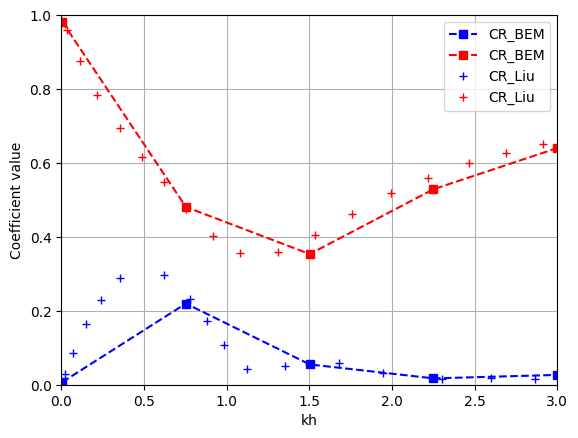

In [18]:
# Analysis of oblique wave interaction with a submerged perforated semicircular breakwater - Yong Liu · Hua Jun Li
# D:\ARCHIVOS_WORKSTATION_UH\FILES_UH\0-2D_CODE_GENERAL\MANUSCRIPT_2D\CODE_TRAINING_BEM\CODE_2_REG_SEMI_CIRCULAR
CR_Liu = np.array([
    [0.0247, 0.0285], [0.0711, 0.0864], [0.1522, 0.1640], [0.2391, 0.2303],
    [0.3576, 0.2894], [0.6231, 0.2981], [0.7785, 0.2310], [0.8792, 0.1714],
    [0.9856, 0.1084], [1.1209, 0.0433], [1.3546, 0.0500], [1.6806, 0.0579],
    [1.9487, 0.0318], [2.3006, 0.0145], [2.5977, 0.0186], [2.8659, 0.0164]
])

CT_Liu = np.array([
    [0.0345, 0.9589], [0.1122, 0.8766], [0.2186, 0.7846], [0.3538, 0.6939],
    [0.4890, 0.6165], [0.6184, 0.5474], [0.7565, 0.4749], [0.9147, 0.4017],
    [1.0786, 0.3570], [1.3116, 0.3597], [1.5360, 0.4056], [1.7574, 0.4619],
    [1.9962, 0.5175], [2.2176, 0.5599], [2.4679, 0.5989], [2.6922, 0.6280],
    [2.9108, 0.6523]
])

# figure(15)
plt.figure(15)

# plot(kh, KT, 'bs')
# 'bs' stands for blue squares
plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CR_BEM')

plt.plot(CR_Liu[:,0], CR_Liu[:,1], 'b+', label='CR_Liu')
plt.plot(CT_Liu[:,0], CT_Liu[:,1], 'r+', label='CR_Liu')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

# plt.savefig("CR_CT.pdf")

# Optional: display the plot
plt.show()

In [19]:
CR
# array([0.0037682 , 0.2779033 , 0.0695805 , 0.01684102, 0.0336889 ])

array([0.00678816, 0.21965844, 0.05495872, 0.01718228, 0.02656801])

In [20]:
CT
# array([0.98145551, 0.48169493, 0.49724375, 0.6549464 , 0.7434269 ])

array([0.98246513, 0.48093618, 0.35356561, 0.52894521, 0.64025767])